<a href="https://colab.research.google.com/github/AbdulWahabSidiqui/portfolio-projects/blob/main/Space_Missions_Analysis_(start).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [ ]:
%pip install iso3166

### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [ ]:
%pip install --upgrade plotly

### Import Statements

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta
import calendar

### Notebook Presentation

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [ ]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

Preliminary Data Exploration

The dataset contains 4,324 rows and 9 columns. The columns include Organisation, Location, Date, Detail, Rocket_Status, Price, and Mission_Status, along with two unnamed columns.There are total 3360 Nan values inside price and no duplicated values.

In [ ]:
print(df_data.shape)
print(df_data.columns)

In [ ]:
print(df_data.isna().sum())
df_data.duplicated().sum()

## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data.

In [ ]:
df_data = df_data.drop(["Unnamed: 0.1", "Unnamed: 0"], axis=1)
df_data.columns

In [ ]:
df_data.isna().sum()
df_data.drop_duplicates(inplace=True)
df_data.duplicated().sum()

df_data["Price"] = pd.to_numeric(df_data["Price"],errors="coerce")
df_data["Price"].dtype

df_data.isna().sum()


## Descriptive Statistics

In [ ]:
df_data.describe()

In [ ]:
df_data.describe(include="object")
df_data.isna().sum()

# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [ ]:
launches_by_org = df_data["Organisation"].value_counts()


In [ ]:
plt.figure(figsize=(12,6))
plt.bar(launches_by_org.index,launches_by_org.values)

plt.xlabel("Organizations")
plt.ylabel("Number of Missions launched")
plt.title("Number of Missions launched by Organizations")

plt.xticks(rotation=90)
plt.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned?

In [ ]:
rocket_status = df_data["Rocket_Status"].value_counts()
rocket_status

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(rocket_status.index,rocket_status.values)

plt.xlabel("Rocket Status")
plt.ylabel("Number of Rockets")
plt.title("Number of Active vs Retired Rockets")

plt.xticks(rotation=90)
plt.show()

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [ ]:
mission_status = df_data["Mission_Status"].value_counts()
mission_status

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(mission_status.index,mission_status.values)

plt.xlabel("Mission Status")
plt.ylabel("Number of Missions")
plt.title("Distribution of Mission Status")

plt.xticks(rotation=90)
plt.show()

# How Expensive are the Launches?

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values).

In [ ]:
price_data = df_data["Price"].dropna()
price_data

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(price_data,bins=30)

plt.xlabel("Launch Price (Usd Millions)")
plt.ylabel("Number of Launches")
plt.title("Distribution of Launch Prices")

plt.xticks(range(0,501,50))

plt.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map.
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [ ]:
df_data["Location"].head()
df_data["Country"] = df_data["Location"].str.split(",").str[-1].str.strip()
df_data["Country"] = df_data["Country"].replace({
    "Russia": "Russian Federation",
    "New Mexico": "USA",
    "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "USA",
    "Barents Sea": "Russian Federation",
    "Gran Canaria": "USA"
})
df_data["Country"] = df_data["Country"].replace({
    "North Korea": "Korea, Democratic People's Republic of",
    "South Korea": "Korea, Republic of"
})
df_data["Country"] = df_data["Country"].replace({
    "Iran": "Iran, Islamic Republic of"
})
df_data["Country"] = df_data["Country"].replace({
    "Pacific Ocean": "Kiribati"
})
df_data["Country_Code"] = df_data["Country"].apply(
    lambda country: countries.get(country).alpha3
)
df_data[["Country","Country_Code"]].drop_duplicates()

In [ ]:
launches_by_country = df_data["Country_Code"].value_counts()
launches_by_country.head()

In [ ]:
fig = px.choropleth(
    locations = launches_by_country.index,
    color = launches_by_country.values,
    locationmode = "ISO-3",
    color_continuous_scale= "Viridis",
    title = "Number of Launches by Country"
)
fig.show()

# Use a Choropleth Map to Show the Number of Failures by Country


In [ ]:
df_data["Mission_Status"].value_counts()
failed_missions = df_data[df_data['Mission_Status'] != "Success"]
failure_by_countries = failed_missions["Country_Code"].value_counts()
failure_by_countries.head(10)

In [ ]:
fig = px.choropleth(
    locations = failure_by_countries.index,
    color = failure_by_countries.values,
    locationmode = "ISO-3",
    color_continuous_scale= "Reds",
    title = "Number of Failures by Country"
)
fig.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status.

In [ ]:
fig = px.sunburst(
    df_data,
    path= ["Country","Organisation","Mission_Status"],
    title= "Space Mission by Countries, Organisations and Mission Status"
)
fig.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [ ]:
df_data["Price"] = pd.to_numeric(df_data["Price"],errors="coerce")
total_spending = df_data.groupby("Organisation")["Price"].sum().sort_values(ascending=False)
top_10_spending = total_spending.head(10)

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(top_10_spending.index,top_10_spending.values)
plt.xlabel("Total Spending (Usd Millions)")
plt.ylabel("Organisations")
plt.title("Total Amount of Money Soent by Organisations")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Analyse the Amount of Money Spent by Organisation per Launch

In [ ]:
average_spending = df_data.groupby("Organisation")["Price"].mean().sort_values(ascending=False)
top_10_average = average_spending.head(10)

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(top_10_average.index,top_10_average.values)
plt.xlabel("Average Cost Per Launch (Usd Millions)")
plt.ylabel("Organisations")
plt.title("Average Amount of Money Spent by Organisations per Launch")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Chart the Number of Launches per Year

In [ ]:
df_data["Date"] = pd.to_datetime(df_data["Date"],format="mixed",utc=True)
df_data["Year"] = df_data["Date"].dt.year
df_data["Year"].head(10)
launches_per_year = df_data.groupby("Year").size()
launches_per_year.head()

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(launches_per_year.index,launches_per_year.values)
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.title("Number of Launches Per Year")
plt.grid()
plt.show()

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart.

In [ ]:
monthly_launches = df_data.resample("ME",on="Date").size()
monthly_launches.idxmax, monthly_launches.max()
rolling_avg = monthly_launches.rolling(12).mean()

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(
    monthly_launches.index,
    monthly_launches.values,
    label = "Monthly Launches"
)
plt.plot(
    rolling_avg.index,
    rolling_avg.values,
    label = "12-Month Rolling Average"
)
plt.xlabel("Date")
plt.ylabel("Number Of Launches")
plt.title("Number Of Launches On Month on Month")
plt.legend()
plt.grid()
plt.show()

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [ ]:
df_data["Month"] = df_data["Date"].dt.month
launches_per_month = df_data.groupby("Month").size()
launches_per_month.idxmax, launches_per_month.max()
launches_per_month.idxmin, launches_per_month.min()
launches_per_month.index = [calendar.month_name[month] for month in launches_per_month.index]

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(launches_per_month.index,launches_per_month.values)
plt.xlabel("Month")
plt.ylabel("Number of Launches")
plt.title("Number of Launches Per Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# How has the Launch Price varied Over Time?

Create a line chart that shows the average price of rocket launches over time.

In [ ]:
price_count_per_year = df_data.groupby(df_data["Date"].dt.year)["Price"].count()
average_price_per_year = df_data.groupby(df_data["Date"].dt.year)["Price"].mean()
average_price_per_year = average_price_per_year.dropna()

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(average_price_per_year.index,average_price_per_year.values)
plt.xlabel("Year")
plt.ylabel("Average Launch Price (USD millions)")
plt.title("Average Rocket Launch Price Over Time")
plt.grid()
plt.show()

# Chart the Number of Launches over Time by the Top 10 Organisations.

How has the dominance of launches changed over time between the different players?

In [ ]:
top_10_organisations = df_data["Organisation"].value_counts().head(10).index
top_10_data = df_data[df_data["Organisation"].isin(top_10_organisations)]

In [ ]:
launches_by_org_per_year = top_10_data.groupby([top_10_data["Date"].dt.year,"Organisation"]).size()

In [ ]:
launches_by_org_per_year = launches_by_org_per_year.unstack(fill_value=0)
launches_by_org_per_year.head()

In [ ]:
plt.figure(figsize=(14,7))
for organisation in top_10_organisations:
  plt.plot(
      launches_by_org_per_year.index,
      launches_by_org_per_year[organisation],
      label=organisation
  )
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.title("Number of Launches Over Time by Top 10 Organisations")
plt.legend()
plt.grid()
plt.show()

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991.

In [ ]:
df_data["Organisation"].value_counts().head(20)
cold_war_data = df_data[df_data["Date"].dt.year <= 1991]
usa_ussr = cold_war_data[cold_war_data["Country"].isin(["USA", "Russian Federation"])]
usa_ussr_launches = usa_ussr.groupby([usa_ussr["Date"].dt.year,"Country"]).size()
usa_ussr_launches = usa_ussr_launches.unstack(fill_value=0)

In [ ]:
plt.figure(figsize=(14,7))
for country in usa_ussr_launches.columns:
  plt.plot(
      usa_ussr_launches.index,
      usa_ussr_launches[country],
      label=country
  )
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.title("Cold War Space Race: USA vs USSR")
plt.grid()
plt.legend()
plt.show()

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches.

In [ ]:
ussr_launches = df_data[
    df_data["Country"].isin(["Russian Federation", "Kazakhstan"])
].shape[0]
usa_launches = df_data[
    df_data["Country"] == "USA"
].shape[0]
pie_data = pd.DataFrame({
    "Country": ["USSR", "USA"],
    "Launches": [ussr_launches, usa_launches]
})
pie_data

In [ ]:
fig = px.pie(
    pie_data,
    names="Country",
    values="Launches",
    title="Total Space Launches: USA vs USSR"
)
fig.show()

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [ ]:
df_data["Superpowers"] = df_data["Country"].replace({
    "Russian Federation": "USSR",
    "Kazakhstan": "USSR",
    "USA": "USA"
})
superpower_data = df_data[df_data['Superpowers'].isin(["USA","USSR"])]
launches_by_superpower = superpower_data.groupby(
    [superpower_data["Date"].dt.year, "Superpowers"]
).size()
launches_by_superpower = launches_by_superpower.unstack(fill_value=0)

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(
    launches_by_superpower.index,
    launches_by_superpower["USA"],
    label="USA"
)
plt.plot(
    launches_by_superpower.index,
    launches_by_superpower["USSR"],
    label="USSR"
)
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.title("Year-on-Year Space Launches: USA vs USSR")
plt.grid()
plt.legend()
plt.show()

## Chart the Total Number of Mission Failures Year on Year.

In [ ]:
failed_missions = df_data[df_data["Mission_Status"] != "Success"]
failure_per_year = failed_missions.groupby(
    failed_missions["Date"].dt.year
).size()

/tmp/ipykernel_1876/82014536.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


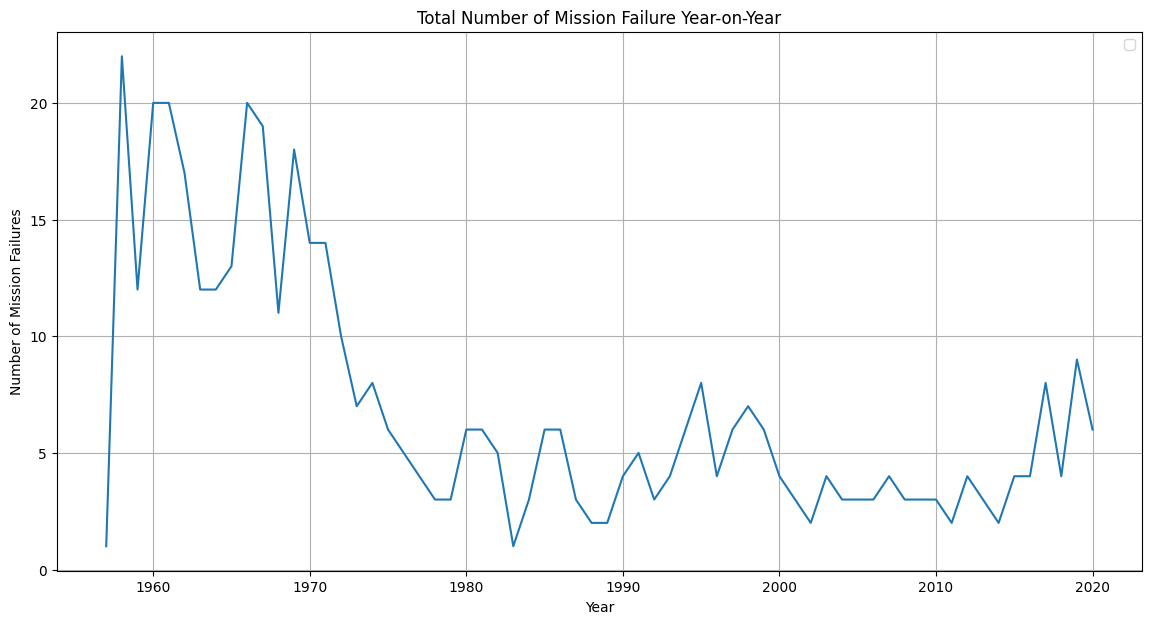

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(
    failure_per_year.index,
    failure_per_year.values,
)
plt.xlabel("Year")
plt.ylabel("Number of Mission Failures")
plt.title("Total Number of Mission Failure Year-on-Year")
plt.grid()
plt.legend()
plt.show()

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time?

In [ ]:
total_missions_per_year = df_data.groupby(
    df_data["Date"].dt.year
).size()
failures_per_year = df_data[
    df_data["Mission_Status"] != "Success"
].groupby(
    df_data["Date"].dt.year
).size()
failure_percentage = (failures_per_year / total_missions_per_year) * 100
failure_percentage = failure_percentage.fillna(0)
failure_percentage


,0
Date,
1957,33.33
1958,78.57
1959,60.00
1960,51.28
1961,38.46
...,...
2016,4.44
2017,8.70
2018,3.42


/tmp/ipykernel_1876/207097362.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


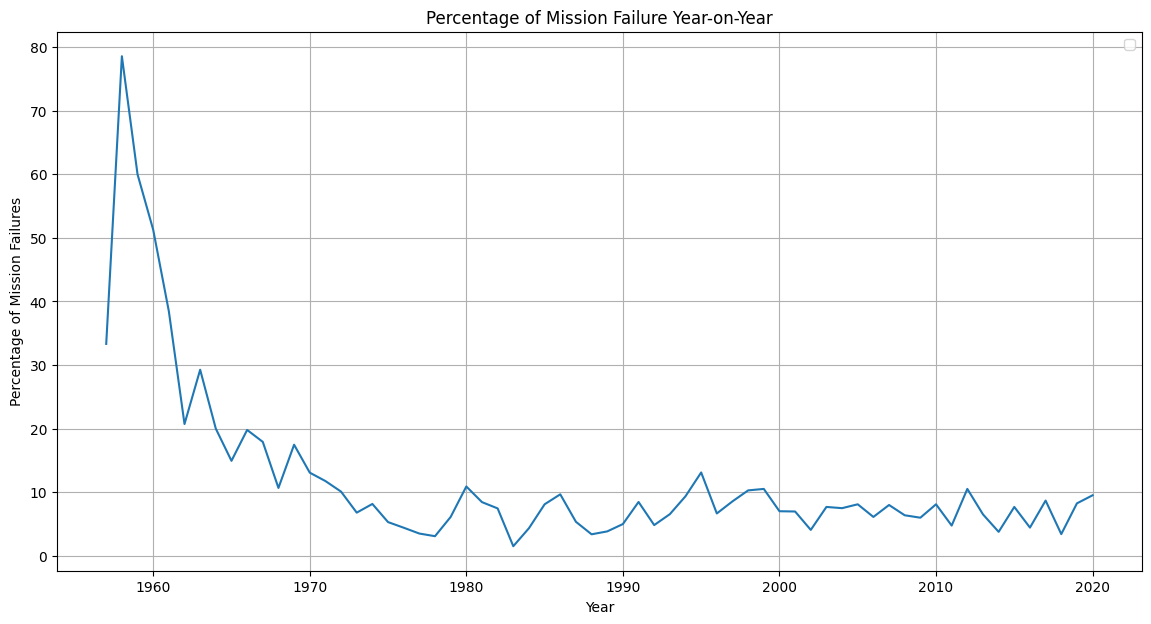

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(
    failure_percentage.index,
    failure_percentage.values,
)
plt.xlabel("Year")
plt.ylabel("Percentage of Mission Failures")
plt.title("Percentage of Mission Failure Year-on-Year")
plt.grid()
plt.legend()
plt.show()

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches?

In [ ]:
df_data["Year"] = df_data["Date"].dt.year
launches_untill_2020 = df_data[df_data["Year"] <= 2020]
launches_by_country_year = launches_untill_2020.groupby(["Year","Country"]).size()
country_in_lead = launches_by_country_year.groupby(
    level="Year"
).idxmax()
country_in_lead = country_in_lead.apply(lambda x: x[1])
lead_count = launches_by_country_year.groupby(
    level="Year"
).max()
leader_by_year = pd.DataFrame({
    "Country":country_in_lead,
    "Launches":lead_count
})
leader_by_year

,Country,Launches
Year,,
1957,Kazakhstan,2
1958,USA,23
1959,USA,16
1960,USA,30
1961,USA,43
...,...,...
2016,USA,27
2017,USA,30
2018,China,39


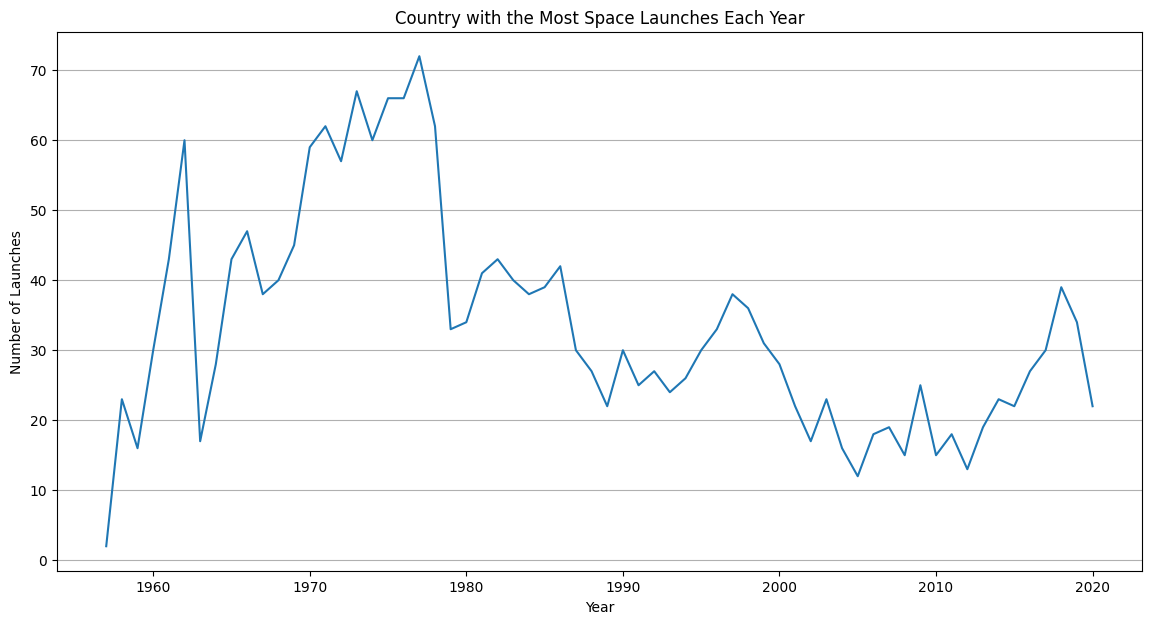

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(
    leader_by_year.index,
    leader_by_year["Launches"],
)
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.title("Country with the Most Space Launches Each Year")
plt.grid(axis="y")
plt.show()

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020?

In [ ]:
launches_by_org_year = df_data.groupby(
    ["Year","Organisation"]
).size()
org_leaders = launches_by_org_year.reset_index(name="Launches")
org_leaders = org_leaders.loc[
    org_leaders.groupby("Year")["Launches"].idxmax()
]
org_leaders = org_leaders.sort_values("Year")

In [ ]:
org_leaders[
    org_leaders["Year"].between(1970, 1989)
]
org_leaders[
    org_leaders["Year"].isin([2018,2019,2020])
]

,Year,Organisation,Launches
616,2018,CASC,37
632,2019,CASC,27
649,2020,CASC,19


In [ ]:
fig = px.bar(
    org_leaders,
    x="Year",
    y="Launches",
    hover_name="Organisation",
    title="Organisation with the Most Space Launches Each Year"
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Number of Launches"
)

fig.show()